<a href="https://colab.research.google.com/github/alokchoudharyguliya/TimeSeriesModel/blob/main/Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --quiet pmdarima statsmodels matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.0 MB/s eta 0:00:00


In [2]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

In [4]:
periods=120
time_idx=pd.date_range("2015-01-01",periods=periods,freq="M")
trend=np.linspace(50,120,periods)
season=10*np.sin(2*np.pi*time_idx.month/12)
noise=np.random.normal(0,5,periods)
ts=trend+season+noise

/tmp/ipython-input-219/258402564.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_idx=pd.date_range("2015-01-01",periods=periods,freq="M")


In [6]:
data=pd.DataFrame({"Date":time_idx,"Value":ts})
data.set_index("Date",inplace=True)
data.head()

,Value
Date,
2015-01-31,55.370786
2015-02-28,59.072971
2015-03-31,55.956818
2015-04-30,62.678766
2015-05-31,51.943462


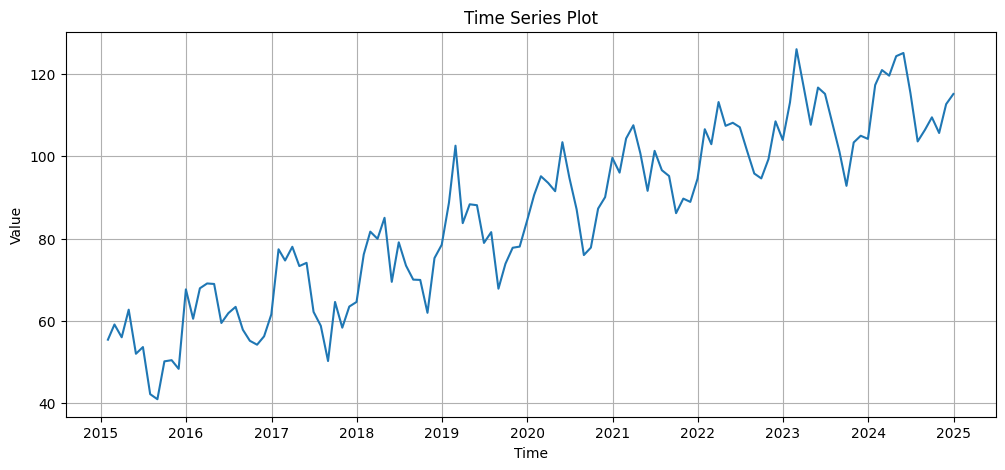

In [7]:
plt.figure(figsize=(12,5))
plt.plot(data.Value)
plt.title("Time Series Plot")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [8]:
data.Value=data.Value.interpolate()

In [9]:
z=np.abs((data.Value-data.Value.mean())/data.Value.std())
data['Value_clean']=np.where(z>3,data.Value.median(),data.Value)

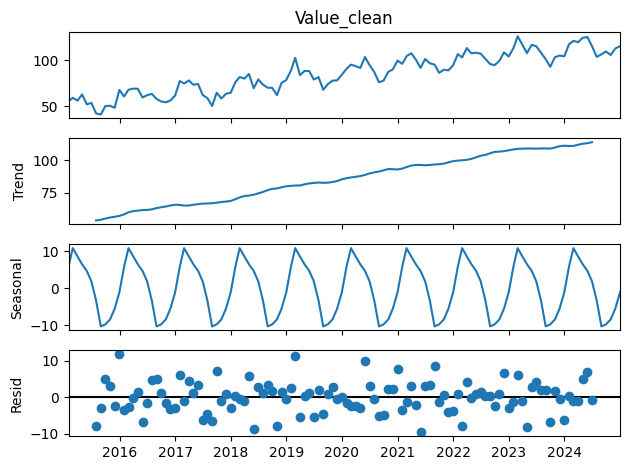

In [10]:
decomp=seasonal_decompose(data.Value_clean.dropna(),model="additive",period=12)
decomp.plot()
plt.show()

In [15]:
train_size = len(data) - 12
train, test = data.Value_clean.iloc[:train_size], data.Value_clean.iloc[train_size:]

print(f"Training set size: {len(train)}")
print(f"Test set size: {len(test)}")

Training set size: 108
Test set size: 12


In [16]:
model=pm.auto_arima(train,seasonal=True,m=12,trace=True,error_action="ignore",suppress_warnings=False)
model.summary()

Performing stepwise search to minimize aic


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optim

 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.81 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=740.488, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=730.181, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=734.078, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=738.878, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=738.569, Time=0.06 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_date

 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=723.192, Time=0.34 sec


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA p

 ARIMA(0,1,2)(1,0,2)[12] intercept   : AIC=689.223, Time=1.68 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=inf, Time=2.70 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


 ARIMA(1,1,1)(1,0,2)[12]             : AIC=695.223, Time=2.31 sec

Best model:  ARIMA(1,1,1)(1,0,2)[12] intercept
Total fit time: 41.808 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  108
Model:             SARIMAX(1, 1, 1)x(1, 0, [1, 2], 12)   Log Likelihood                -337.224
Date:                                 Sun, 01 Mar 2026   AIC                            688.447
Time:                                         17:58:21   BIC                            707.157
Sample:                                     01-31-2015   HQIC                           696.032
                                          - 12-31-2023                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0054      0.008      0.651      0.515      -0.011       0.022
ar.L1          0.0146      0.128      0.114      0.910      -0.237       0.266
ma.L1         -0.9899      0.189     -5.248      0.000      -1.360      -0.620
ar.S.L12       0.9907      0.014     69.365      0.000       0.963       1.019
ma.S.L12      -0.9775      0.146     -6.715      0.000      -1.263      -0.692
ma.S.L24       0.1846      0.136      1.357      0.175      -0.082       0.451
sigma2        25.1346      5.796      4.337      0.000      13.776      36.494
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.00
Prob(Q):                              0.97   Prob(JB):                         0.61
Heteroskedasticity (H):               0.98   Skew:                             0.23
Prob(H) (two-sided):                  0.95   Kurtosis:                         3.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

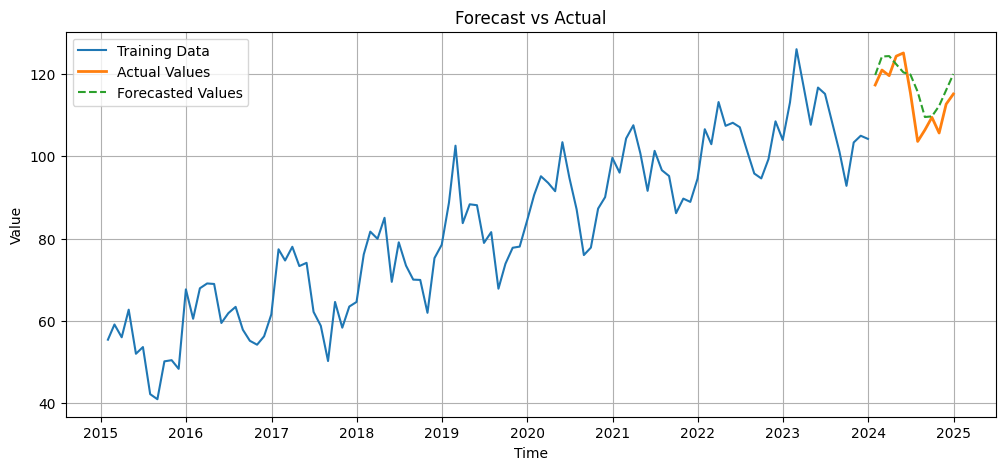

In [17]:
forecast=model.predict(n_periods=12)
forecast=pd.Series(forecast,index=test.index)
plt.figure(figsize=(12,5))
plt.plot(train,label="Training Data")
plt.plot(test, label="Actual Values", linewidth=2)
plt.plot(forecast, label="Forecasted Values", linestyle="--")
plt.title("Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

periods=120
time_idx=pd.date_range("2015-01-01",periods=periods,freq="M")
trend=np.linspace(50,120,periods)
season=10*np.sin(2*np.pi*time_idx.month/12)
noise=np.random.normal(0,5,periods)
ts=trend+season+noise

data=pd.DataFrame({"Date":time_idx,"Value":ts})
data.set_index("Date",inplace=True)
data.head()

plt.figure(figsize=(12,5))
plt.plot(data.Value)
plt.title("Time Series Plot")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()

data.Value=data.Value.interpolate()

z=np.abs((data.Value-data.Value.mean())/data.Value.std())
data['Value_clean']=np.where(z>3,data.Value.median(),data.Value)

decomp=seasonal_decompose(data.Value_clean.dropna(),model="additive",period=12)
decomp.plot()
plt.show()

train_size = len(data) - 12
train, test = data.Value_clean.iloc[:train_size], data.Value_clean.iloc[train_size:]

print(f"Training set size: {len(train)}")
print(f"Test set size: {len(test)}")

model=pm.auto_arima(train,seasonal=True,m=12,trace=True,error_action="ignore",suppress_warnings=False)
model.summary()

forecast=model.predict(n_periods=12)
forecast=pd.Series(forecast,index=test.index)
plt.figure(figsize=(12,5))
plt.plot(train,label="Training Data")
plt.plot(test, label="Actual Values", linewidth=2)
plt.plot(forecast, label="Forecasted Values", linestyle="--")
plt.title("Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()